In [7]:
# IMPORT SECTION
import datetime # for the dates and time
import pandas as pd # data frames aka  the n.n data
import numpy as np
import matplotlib.pyplot as plt # for the plots
import pandas_datareader.data as web # in industry we use GCP (Ggle Cloud Plt)


In [8]:
data = {
    'Asset_ID': ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10'],
    'Sector': ['Tech', 'Fin', 'Tech', 'Energy', 'Fin', 'Tech', 'Energy', 'Tech', 'Retail', 'Retail'],
    'Returns': [0.05, 0.02, -0.01, 0.08, np.nan, 0.04, 0.15, -0.02, 0.01, 5.0],
    'Volatility': [0.12, 0.08, 0.15, 0.20, 0.10, 0.11, 0.25, 0.13, 0.09, 0.10],
    'Description': ['High growth tech', 'Stable financial', 'Volatile software', 'Oil production', 'Unknown bank', 'AI startup', 'Solar energy', 'E-commerce', 'Store A', 'Store B']
}

In [1]:
stock_ticker = "GFTC" # String : to reprents labels or name s
market_price = 150.25 # Float
share_traded = 1000 #Integer
is_volatile = True # Boolean
print(f"Asset: {stock_ticker}")
print(f"Market Prices:{market_price}")
print(f"Shares Traded: {share_traded}")
print(f"Is Volatile:{is_volatile}")
print(f"Asset: {stock_ticker} | Market Price: {market_price} | Shares Traded: {share_traded}")

Asset: GFTC
Market Prices:150.25
Shares Traded: 1000
Is Volatile:True
Asset: GFTC | Market Price: 150.25 | Shares Traded: 1000


In [ ]:
# MISSING VALUES
# WHAT DO YOU DO WHEN YOU HAVE MISSING VALUES?
# THE RISK OF MISSING VALUES IS TO HAVE BIAS RESULTS
# MAR/ MCAR/ MNAR
# MAR : MISSSING CPLTELY AT RANDOM
# MACR : MISSING RELATED TO OBS VARIABLE
# MNAR: MISSING RELATED TO THE VALUE ITSELF


In [10]:
# 1. 重新根据最新的 data 字典创建 DataFrame，确保包含 'Returns' 列
df_fin = pd.DataFrame(data)

# 2. 修复语法错误：将逗号改为点号 .fillna()
df_fin['Returns_Imp'] = df_fin['Returns'].fillna(df_fin['Returns'].mean())

display(df_fin.head())

,Asset_ID,Sector,Returns,Volatility,Description,Returns_Imp
0,A1,Tech,0.05,0.12,High growth tech,0.050000
1,A2,Fin,0.02,0.08,Stable financial,0.020000
2,A3,Tech,-0.01,0.15,Volatile software,-0.010000
3,A4,Energy,0.08,0.20,Oil production,0.080000
4,A5,Fin,NaN,0.10,Unknown bank,0.591111


In [11]:
print(f"Gaps filed with the means is not perefect but good. Total NaNs now : {df_fin['Returns_Imp'].isna().sum()}")

Gaps filed with the means is not perefect but good. Total NaNs now : 0


In [13]:
from scipy.stats.mstats import winsorize

# 4. Outliers & Winsorisation
# winsorize 不处理 NaN，因此我们通常在已填充的数据（Returns_Imp）上操作
# limits=[0.05, 0.05] 表示将最小 5% 和最大 5% 的值替换为临界点的值
df_fin['Returns_Winsorized'] = winsorize(df_fin['Returns_Imp'], limits=[0.05, 0.05])

print("Original Returns (with outlier 5.0):")
print(df_fin['Returns_Imp'].tail(3))
print("\nWinsorized Returns (capped):")
display(df_fin.head())

Original Returns (with outlier 5.0):
7   -0.02
8    0.01
9    5.00
Name: Returns_Imp, dtype: float64

Winsorized Returns (capped):


,Asset_ID,Sector,Returns,Volatility,Description,Returns_Imp,Returns_Winsorized
0,A1,Tech,0.05,0.12,High growth tech,0.050000,0.050000
1,A2,Fin,0.02,0.08,Stable financial,0.020000,0.020000
2,A3,Tech,-0.01,0.15,Volatile software,-0.010000,-0.010000
3,A4,Energy,0.08,0.20,Oil production,0.080000,0.080000
4,A5,Fin,NaN,0.10,Unknown bank,0.591111,0.591111


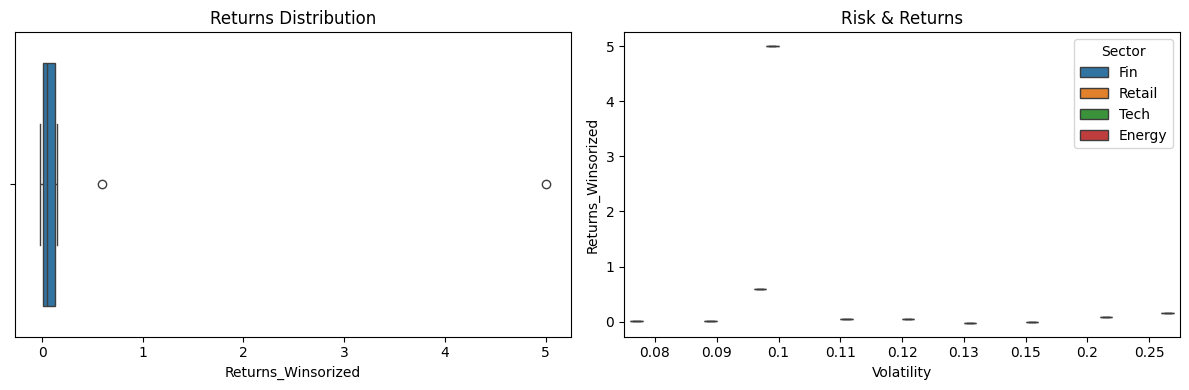

In [17]:
# DATA VIZ (VISUALIZATION)
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)

# Import seaborn
import seaborn as sns

# 1. 绘制第一个箱线图
sns.boxplot(x=df_fin['Returns_Winsorized']).set_title("Returns Distribution")

# 2. 修复：修改 ns 为 sns，修正括号错误，并将 Returns_Clean 改为 Returns_Winsorized
plt.subplot(1,2,2)
sns.boxplot(data=df_fin, x='Volatility', y='Returns_Winsorized', hue='Sector').set_title("Risk & Returns")

plt.tight_layout()
plt.show()

In [ ]:
# the cool econometrics part
# What is the PACKAGE used

In [18]:
import statsmodels.api as sm

In [19]:
X=sm.add_constant(df_fin['Volatility'])
Y= df_fin['Returns_Imp']
model = sm.OLS(Y,X)
Results = model.fit()
print (Results.summary())

                            OLS Regression Results                            
Dep. Variable:            Returns_Imp   R-squared:                       0.048
Model:                            OLS   Adj. R-squared:                 -0.071
Method:                 Least Squares   F-statistic:                    0.4006
Date:                Mon, 15 Jun 2026   Prob (F-statistic):              0.544
Time:                        13:14:00   Log-Likelihood:                -17.862
No. Observations:                  10   AIC:                             39.72
Df Residuals:                       8   BIC:                             40.33
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.4336      1.426      1.006      0.3

In [21]:
#IMPORT A SUB PART OF SKLEARN
from sklearn. cluster import KMeans

In [ ]:
Kmeans = KMeans(n_clusters=3,n_init=10,random_state=42). fit(df_fin[['Returns_Clean','Volatility']])
print ("Assets assigned to risk clusters.")

In [ ]:
# but we need more, we need to PREDUCT
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report #to ease the human reasding
de_fin['Target'] = (df_fin['Sector'']== 'Tech'). astype(int)
X_clf = df_fin[['Returns_clean', 'Volatility']]
Y_clf = df_fin ['Target']


In [ ]:
# FINANCAL DATA ANALYSIS WITH THE INTERNET


In [24]:
import yfinance as yf # Import the yfinance library

start = datetime.datetime(2020, 1, 1)
end = datetime.datetime(2023, 1, 1)

# Fetch S&P 500 data (ticker symbol '^GSPC' for S&P 500 from Yahoo Finance) using yfinance
sp500_data = yf.download('^GSPC', start=start, end=end)

print("S&P 500 Data Head:")
display(sp500_data.head())

/tmp/ipykernel_8047/423023190.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  sp500_data = yf.download('^GSPC', start=start, end=end)
[*********************100%***********************]  1 of 1 completed

S&P 500 Data Head:


Price,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,
2020-01-02,3257.850098,3258.139893,3235.530029,3244.669922,3459930000
2020-01-03,3234.850098,3246.149902,3222.340088,3226.360107,3484700000
2020-01-06,3246.280029,3246.840088,3214.639893,3217.550049,3702460000
2020-01-07,3237.179932,3244.909912,3232.429932,3241.860107,3435910000
2020-01-08,3253.050049,3267.070068,3236.669922,3238.590088,3726840000


In [25]:
# SInce it is more than just simple Data analitycs
# install the SQL package
! pip install pandasql
# to install it you need the excelamtions point and PIP

  Preparing metadata (setup.py) ... done
  Created wheel for pandasql: filename=pandasql-0.7.3-py3-none-any.whl size=26773 sha256=24883432bb1b5394b65583addb7c225f069ae22963b14d5c33d7fcf83db6cc5d
  Stored in directory: /root/.cache/pip/wheels/15/a1/e7/6f92f295b5272ae5c02365e6b8fa19cb93f16a537090a1cf27
Successfully built pandasql


In [26]:
import sqlite3

In [27]:
conn = sqlite3.connect (':memory')
#this create an in-memory SQLite  DB so u use the vm of google

In [28]:
df_fin.to_sql('finance-table',conn,index=False, if_exists='replace')
# then write the existing df_fin to the SQL db

10

In [30]:
#WHAT ARE THE 3 WORD USED IN SQL?
query="SELECT Sector,AVG(Volatility) as Avg_Vol FROM `finance-table` GROUP BY Sector"
spl_results = pd.read_sql_query(query, conn)
display (spl_results)

,Sector,Avg_Vol
0,Energy,0.2250
1,Fin,0.0900
2,Retail,0.0950
3,Tech,0.1275


In [31]:
# what if i want only sql and no more pandas
# i can use a LAMBDA FUCTION
from pandasql import sqldf

In [32]:
pysqldf = lambda q: sqldf(q, globals())

In [34]:
query_ps = """
SELECT Asset_ID,Sector, Returns_Winsorized
FROM df_fin
WHERE Sector = 'Tech'
"""
print (pysqldf(query_ps))

  Asset_ID Sector  Returns_Winsorized
0       A1   Tech                0.05
1       A3   Tech               -0.01
2       A6   Tech                0.04
3       A8   Tech               -0.02


In [35]:
asset_metadata = pd.DataFrame({
    'Asset_ID': ['A1', 'A2', 'A3', 'A4', 'A5'],
    'Full_Name': ['Apple Inc', 'JP Morgan', 'Microsoft', 'Exxon Mobil', 'Goldman Sachs'],
    'Country': ['USA', 'USA', 'USA', 'USA', 'USA']
})

In [37]:
# THE ADVANTAGE OF SQL IS THE POWER OF JOINNING TABLES
# THE MPST USED ONE IS INNER JOIN
# WE WILL DO A API CALL FOR THE FRED
start_fred = datetime.datetime(2000, 1, 1)
end_fred = datetime.datetime(2023, 1, 1)
fred_data = web.DataReader('FEDFUNDS', 'fred', start_fred, end_fred)
fred_df_sql = fred_data.reset_index()

In [ ]:
query_fred= """
SELECT